# Workout Classification 
## EDA

### Setup

In [23]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks

pd.set_option("display.max_columns", 50)
plt.rcParams["axes.grid"] = True

DATA_ROOT = "/Users/xiazheng/Desktop/UVA/Courses25-26/S1P6/ML4QS/Data"

SENSOR_FILES = {
    "accelerometer": ["Accelerometer.csv"],
    "gyroscope":     ["Gyroscope.csv"],
    "linear_acc":    ["Linear Accelerometer.csv", "Linear_Accelerometer.csv"],
    "barometer":     ["Barometer.csv"],
    "orientation":   ["Orientation.csv"],
}
LABEL_ALIASES = {
    "pushups": "Pushups", "pushup": "Pushups",
    "pullups": "Pullups", "pullup": "Pullups", "chinups": "Pullups",
    "squats":  "Squats",  "squat":  "Squats",
}
SENSOR_PREFIX = {
    "accelerometer": "acc",
    "gyroscope":     "gyr",
    "linear_acc":    "lacc",
    "barometer":     "baro",
    "orientation":   "ori",
}

TARGET_HZ   = 50 
TIME_GRAINS = [10, 5, 2]   # window sizes in seconds for the statistics table
FMAX        = 2.5          # upper frequency limit for cadence plot (Hz)
CYCLE_LEN   = 100          # number of points each rep cycle is warped to

### Load all sessions

In [9]:
def canonical(raw):
    key = re.sub(r"[^a-z0-9]", "", raw.lower())
    return LABEL_ALIASES.get(key, raw)

SESSION_RE = re.compile(r"^(?P<workout>.+?)_S(?P<session>\d+)$", re.IGNORECASE)

def find_sessions(root):
    rows = []
    for subj in sorted(os.listdir(root)):
        sp = os.path.join(root, subj)
        if not os.path.isdir(sp): continue
        for folder in sorted(os.listdir(sp)):
            fpath = os.path.join(sp, folder)
            if not os.path.isdir(fpath): continue
            m = SESSION_RE.match(folder)
            workout_raw = m.group("workout") if m else folder
            session_n   = int(m.group("session")) if m else 1
            rows.append(dict(subject=subj, workout=canonical(workout_raw),
                             session=session_n, path=fpath))
    return pd.DataFrame(rows).sort_values(["subject","workout","session"]).reset_index(drop=True)

def load_all(root):
    sessions = find_sessions(root)
    raw = {}
    for _, s in sessions.iterrows():
        raw[s.path] = {
            name: pd.read_csv(fp).rename(columns=lambda c: c.strip().strip('"'))
            for name, candidates in SENSOR_FILES.items()
            for fp in [next((os.path.join(s.path, f) for f in candidates
                             if os.path.exists(os.path.join(s.path, f))), None)]
            if fp
        }
    return sessions, raw

sessions_all, raw_all = load_all(DATA_ROOT)

# subject labels: 01, 02, ...
subj_map = {s: f"{i+1:02d}" for i, s in enumerate(sorted(sessions_all.subject.unique()))}
sessions_all["subject"] = sessions_all["subject"].map(subj_map)

print(f"Loaded {len(sessions_all)} raw sessions")
sessions_all[["subject","workout","session"]]

Loaded 9 raw sessions


,subject,workout,session
0,01,Pullups,1
1,01,Pushups,1
2,01,Squats,1
3,02,Pushups,1
4,02,Pushups,2
5,02,Pushups,3
6,02,Squats,1
7,02,Squats,2
8,02,Squats,3


### Combine sessions per (subject, workout)

For subjects with multiple sessions of the same workout, we concatenate them
into one continuous recording. The time axis is shifted so it runs without
gaps: the first sample of session N+1 starts exactly one sample-interval after
the last sample of session N.

For subjects with only one session the result is identical to the original.
After this step every (subject, workout) has exactly **one** entry in `sessions`
and `raw`.

In [10]:
def hz(df):
    return round(1 / np.median(np.diff(df.iloc[:, 0].to_numpy())), 1)

def concat_sessions(subject, workout, sensor_name, sessions_df, raw_dict):
    """
    Concatenate all sessions for (subject, workout) for one sensor.
    Returns a single DataFrame with a continuous time axis, or None.
    """
    rows = sessions_df[
        (sessions_df.subject == subject) & (sessions_df.workout == workout)
    ].sort_values("session")

    parts  = []
    offset = 0.0
    for _, s in rows.iterrows():
        d = raw_dict[s.path].get(sensor_name)
        if d is None:
            continue
        shifted = d.copy()
        # reset each session to start at 0, then shift by accumulated offset
        shifted.iloc[:, 0] = d.iloc[:, 0] - d.iloc[0, 0] + offset
        # next session starts one sample-interval after the last sample
        offset = float(shifted.iloc[-1, 0]) + 1.0 / hz(d)
        parts.append(shifted)

    return pd.concat(parts, ignore_index=True) if parts else None


# Build combined sessions index and raw dict
# Key in raw_combined: synthetic string "subj_workout" (unique per pair)
sessions_rows = []
raw_combined  = {}

for (subj, work), grp in sessions_all.groupby(["subject", "workout"]):
    key = f"{subj}_{work}"
    n_sessions = len(grp)

    # combine every sensor
    raw_combined[key] = {
        sensor: concat_sessions(subj, work, sensor, sessions_all, raw_all)
        for sensor in SENSOR_FILES
    }

    # compute total duration from accelerometer (most reliable)
    acc = raw_combined[key].get("accelerometer")
    duration = round(acc.iloc[-1, 0] - acc.iloc[0, 0], 1) if acc is not None else None

    sessions_rows.append(dict(
        subject    = subj,
        workout    = work,
        n_sessions = n_sessions,         # how many raw sessions were merged
        duration_s = duration,
        key        = key,
    ))

sessions = pd.DataFrame(sessions_rows).sort_values(["subject","workout"]).reset_index(drop=True)
print("Combined sessions (one row per subject × workout):")
sessions

Combined sessions (one row per subject × workout):


,subject,workout,n_sessions,duration_s,key
0,01,Pullups,1,133.9,01_Pullups
1,01,Pushups,1,157.5,01_Pushups
2,01,Squats,1,152.6,01_Squats
3,02,Pushups,3,120.3,02_Pushups
4,02,Squats,3,155.8,02_Squats


In [11]:
# Verify no large time gaps at session boundaries
print("Boundary check — gaps > 0.1s in combined recordings:")
found_gap = False
for _, s in sessions.iterrows():
    acc = raw_combined[s.key].get("accelerometer")
    if acc is None: continue
    t  = acc.iloc[:, 0].to_numpy()
    dt = np.diff(t)
    gaps = np.where(dt > 0.1)[0]
    if len(gaps):
        print(f"  {s.subject} {s.workout}: {len(gaps)} gap(s) at t={t[gaps].round(2)}")
        found_gap = True
if not found_gap:
    print("  None — all boundaries are clean.")

Boundary check — gaps > 0.1s in combined recordings:
  None — all boundaries are clean.


### Helpers

In [14]:
def magnitude(df):
    return np.sqrt((df.iloc[:, 1:4].to_numpy() ** 2).sum(axis=1))

def get(subject, workout, sensor):
    """Return the combined sensor DataFrame for (subject, workout), or None."""
    row = sessions[(sessions.subject == subject) & (sessions.workout == workout)]
    if row.empty: return None
    return raw_combined[row.iloc[0].key].get(sensor)

subjects = sorted(sessions.subject.unique())
works    = sorted(sessions.workout.unique())

### Session overview

In [15]:
overview_rows = []
for _, s in sessions.iterrows():
    acc = raw_combined[s.key].get("accelerometer")
    if acc is not None:
        overview_rows.append(dict(
            subject    = s.subject,
            workout    = s.workout,
            n_sessions = s.n_sessions,
            total_dur_s= s.duration_s,
            n_rows     = len(acc),
            hz         = hz(acc),
        ))
overview = pd.DataFrame(overview_rows)
display(overview)
print("\nSessions merged per (subject, workout):")
print(sessions.pivot_table(index="subject", columns="workout",
                           values="n_sessions", aggfunc="sum", fill_value=0).to_string())

,subject,workout,n_sessions,total_dur_s,n_rows,hz
0,01,Pullups,1,133.9,6729,50.3
1,01,Pushups,1,157.5,7919,50.3
2,01,Squats,1,152.6,7671,50.3
3,02,Pushups,3,120.3,6032,50.2
4,02,Squats,3,155.8,7815,50.2



Sessions merged per (subject, workout):
workout  Pullups  Pushups  Squats
subject                          
01             1        1       1
02             0        3       3


## 1. Raw time-series per workout — all subjects

Each column is a subject; each pair of rows is one workout (axes on top, magnitude below).
Missing (subject, workout) combinations show "no data".

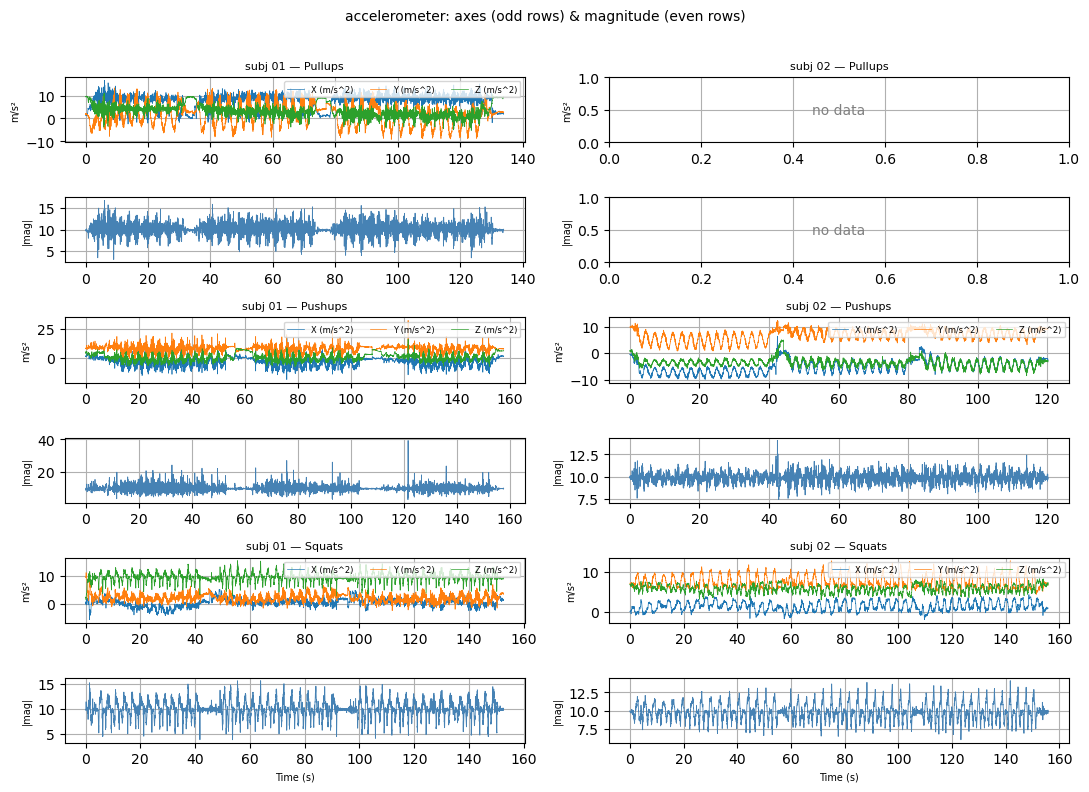

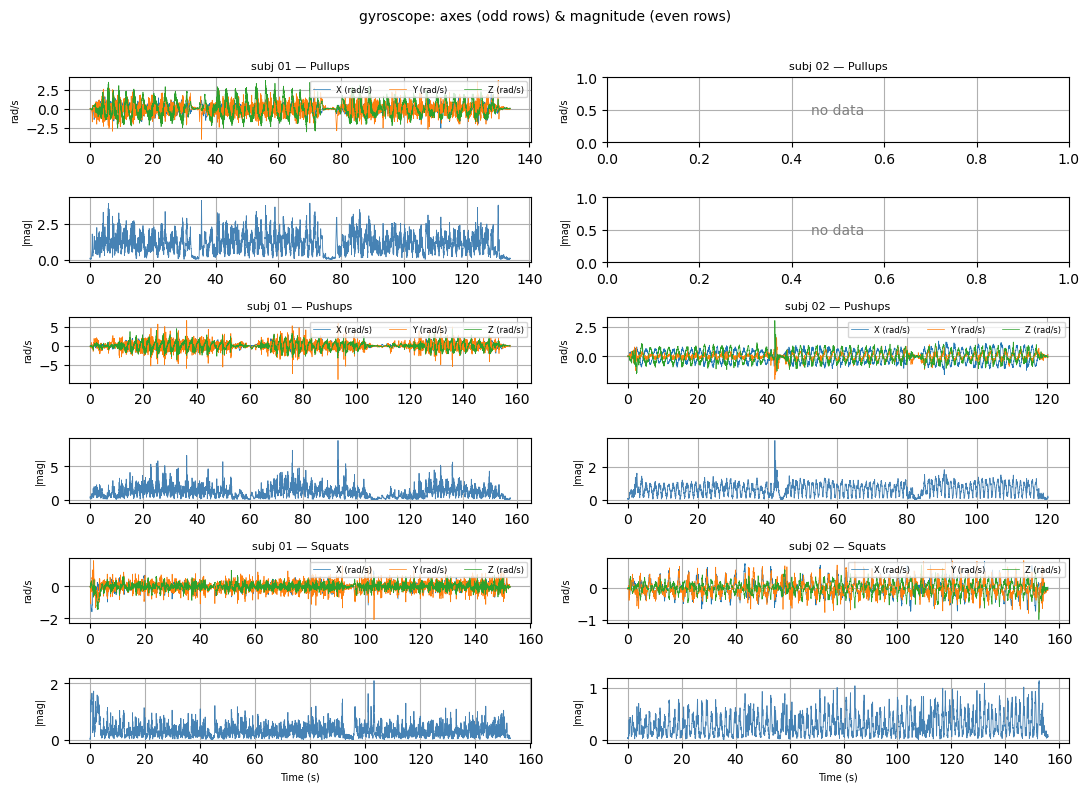

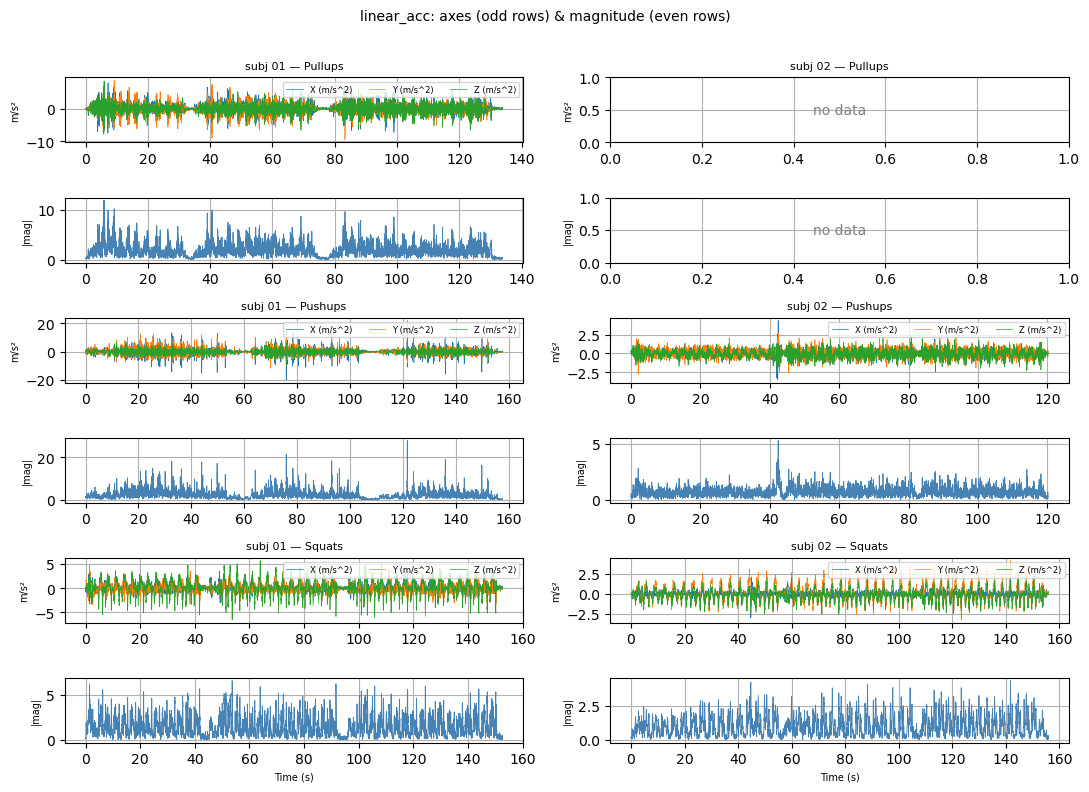

In [17]:
for sensor, unit in [("accelerometer","m/s²"), ("gyroscope","rad/s"), ("linear_acc","m/s²")]:
    fig, axes = plt.subplots(len(works) * 2, len(subjects),
                             figsize=(5.5 * len(subjects), 2.6 * len(works)),
                             squeeze=False)
    for wi, work in enumerate(works):
        for si, subj in enumerate(subjects):
            ax_raw = axes[wi * 2,     si]
            ax_mag = axes[wi * 2 + 1, si]
            d = get(subj, work, sensor)
            if d is not None:
                t = d.iloc[:, 0].to_numpy()
                for c in d.columns[1:4]:
                    ax_raw.plot(t, d[c].to_numpy(), lw=0.5, label=c)
                ax_raw.legend(fontsize=6, ncol=3, loc="upper right")
                ax_mag.plot(t, magnitude(d), lw=0.6, color="steelblue")
            else:
                for ax in (ax_raw, ax_mag):
                    ax.text(0.5, 0.5, "no data", ha="center", va="center",
                            transform=ax.transAxes, color="grey")
            ax_raw.set_title(f"subj {subj} — {work}", fontsize=8)
            ax_raw.set_ylabel(unit, fontsize=7)
            ax_mag.set_ylabel("|mag|", fontsize=7)
            if wi == len(works) - 1:
                ax_mag.set_xlabel("Time (s)", fontsize=7)
    fig.suptitle(f"{sensor}: axes (odd rows) & magnitude (even rows)", y=1.01, fontsize=10)
    plt.tight_layout(); plt.show()

## 2. Magnitude distributions — violin plots

Session length is irrelevant here: we pool all samples from every session a subject has
for a given workout and compare the resulting distribution.

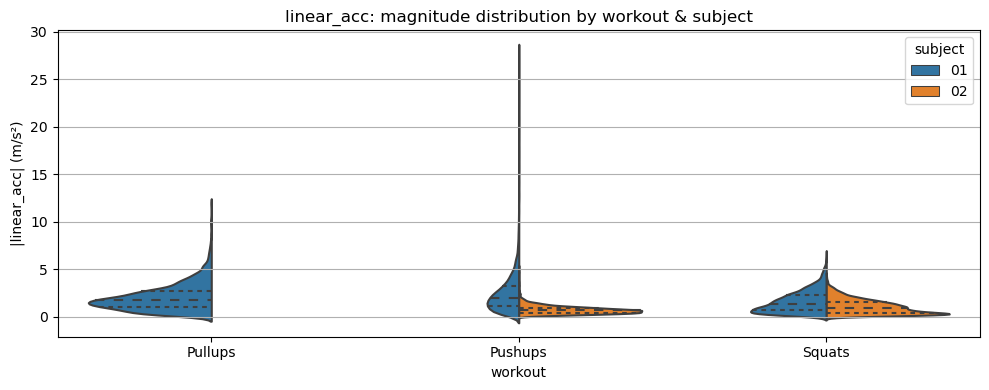

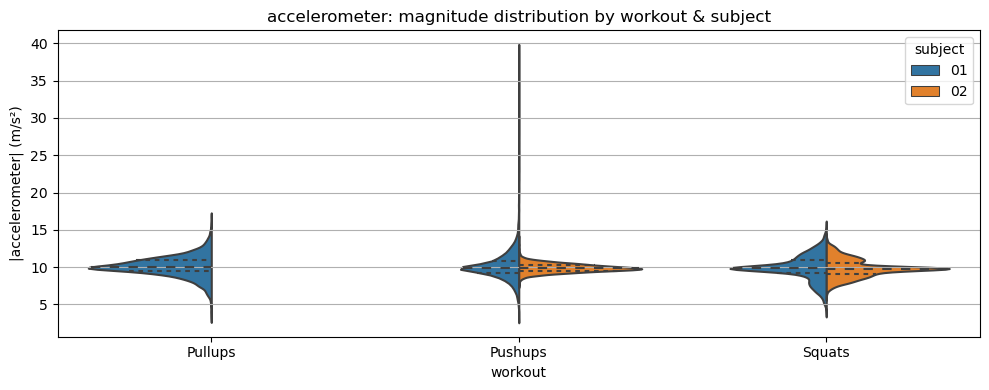

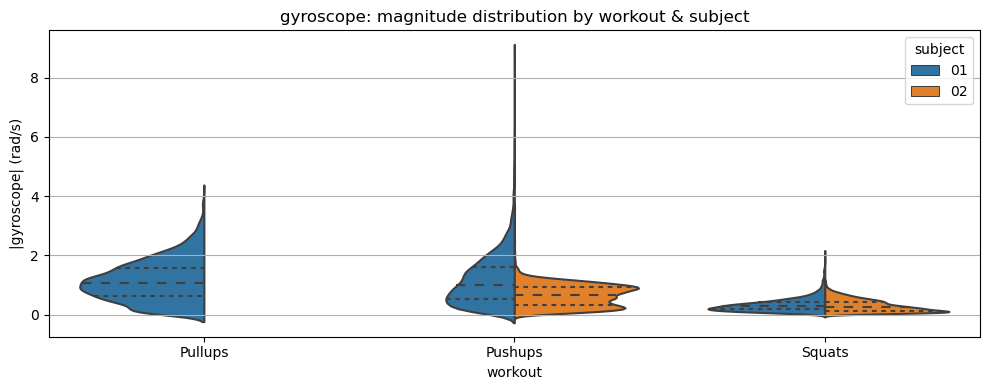

In [19]:
for sensor, unit in [("linear_acc","m/s²"), ("accelerometer","m/s²"), ("gyroscope","rad/s")]:
    rows = []
    for _, s in sessions.iterrows():
        d = raw_combined[s.key].get(sensor)
        if d is None: continue
        for v in magnitude(d):
            rows.append({"subject": s.subject, "workout": s.workout, "mag": v})
    df_long = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.violinplot(data=df_long, x="workout", y="mag",
                   hue="subject", split=len(subjects) == 2,
                   inner="quartile", ax=ax)
    ax.set_title(f"{sensor}: magnitude distribution by workout & subject")
    ax.set_ylabel(f"|{sensor}| ({unit})")
    plt.tight_layout(); plt.show()

## 3. Magnitude on the Normalized time axis [0 → 1]

Rescaling each session to [0, 1] removes the effect of different durations so
session-level structure (e.g. fatigue toward the end, warm-up at the start) is
comparable across subjects and sessions.

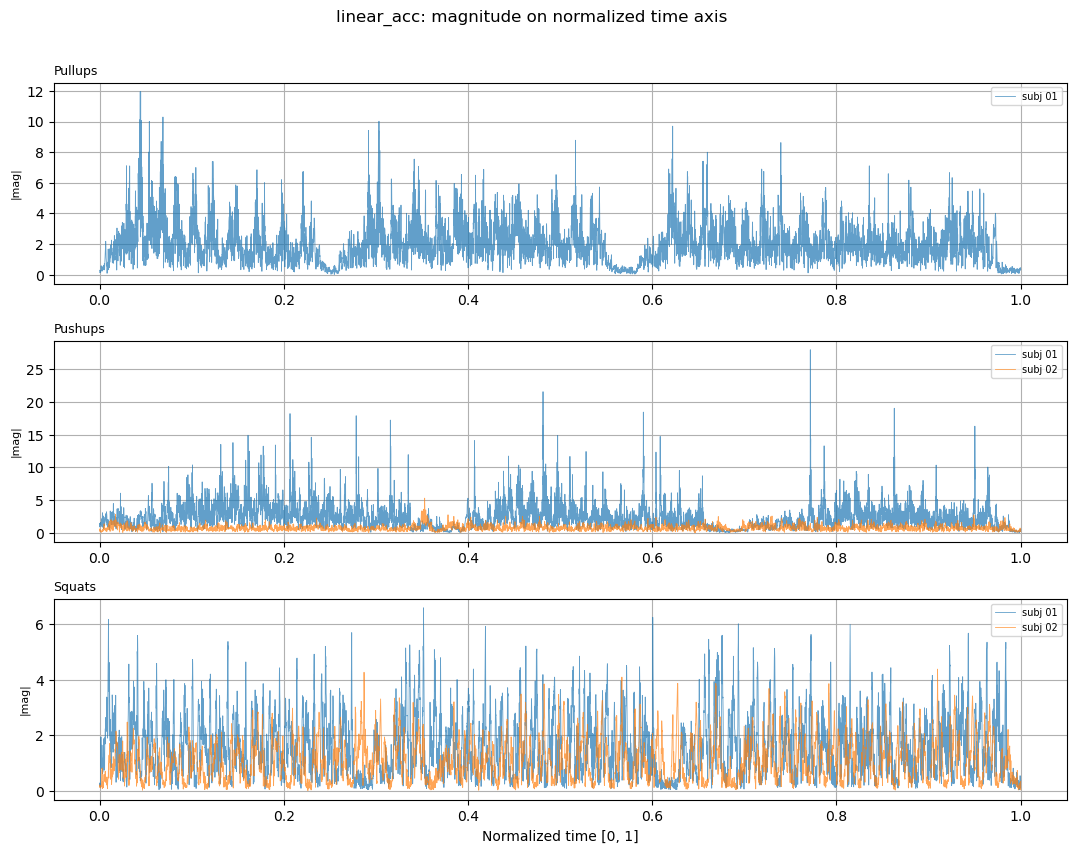

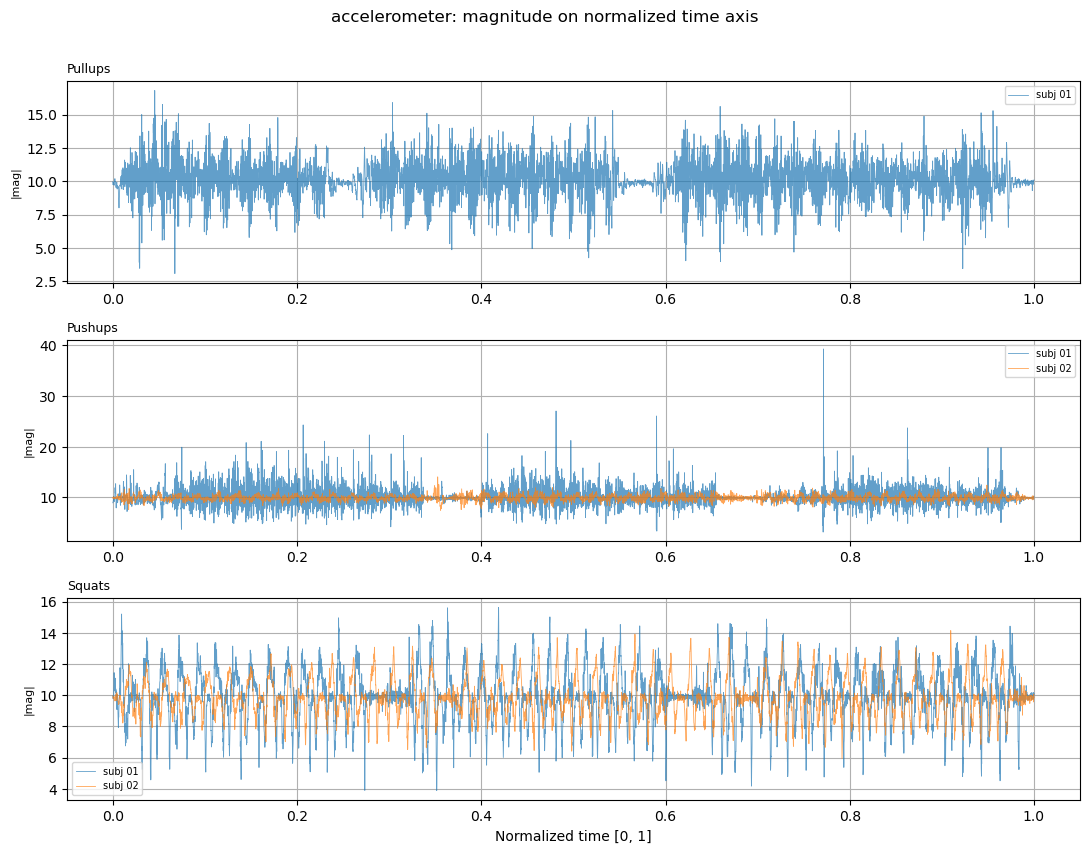

In [20]:
for sensor in ["linear_acc", "accelerometer"]:
    fig, axes = plt.subplots(len(works), 1,
                             figsize=(11, 2.8 * len(works)), squeeze=False)
    for ax, work in zip(axes[:, 0], works):
        for subj in subjects:
            d = get(subj, work, sensor)
            if d is None: continue
            t = d.iloc[:, 0].to_numpy()
            t_norm = (t - t[0]) / (t[-1] - t[0])
            ax.plot(t_norm, magnitude(d), lw=0.6, alpha=0.7, label=f"subj {subj}")
        ax.set_title(work, loc="left", fontsize=9)
        ax.set_ylabel("|mag|", fontsize=8)
        ax.legend(fontsize=7)
    axes[-1, 0].set_xlabel("Normalized time [0, 1]")
    fig.suptitle(f"{sensor}: magnitude on normalized time axis", y=1.01)
    plt.tight_layout(); plt.show()

## 4. Rep-cycle overlay (mean ± std)

Each rep is detected as a peak in the magnitude, then warped to `CYCLE_LEN` points.
Overlaying the mean ± std of all reps gives a "fingerprint" of each workout that is
independent of session length, cadence, or number of reps — the shape is what matters.

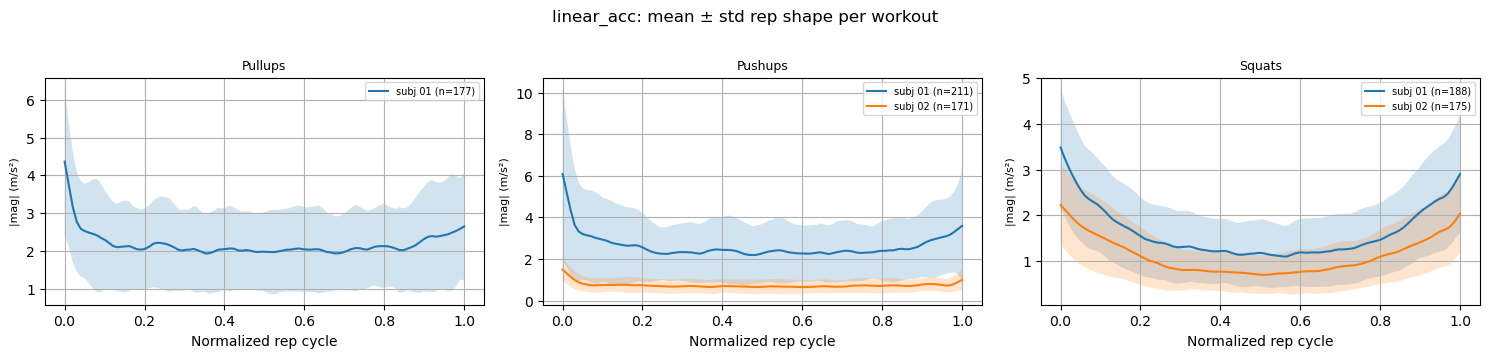

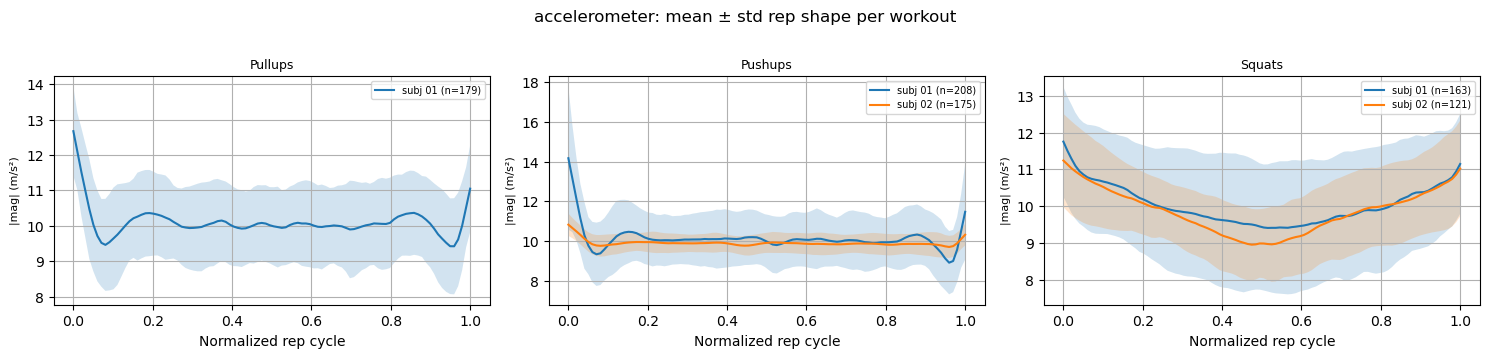

In [21]:
def extract_cycles(df, fs=50.0, n_points=CYCLE_LEN):
    m = magnitude(df)
    peaks, _ = find_peaks(m,
                          distance=int(0.5 * fs),
                          prominence=m.std() * 0.5)
    if len(peaks) < 2:
        return np.empty((0, n_points))
    x_grid = np.linspace(0, 1, n_points)
    cycles = []
    for i in range(len(peaks) - 1):
        seg = m[peaks[i]: peaks[i + 1]]
        if len(seg) < 5: continue
        cycles.append(np.interp(x_grid, np.linspace(0, 1, len(seg)), seg))
    return np.array(cycles)

for sensor in ["linear_acc", "accelerometer"]:
    fig, axes = plt.subplots(1, len(works),
                             figsize=(5 * len(works), 3.5), squeeze=False)
    x = np.linspace(0, 1, CYCLE_LEN)
    for ax, work in zip(axes[0], works):
        for subj in subjects:
            d = get(subj, work, sensor)
            if d is None: continue
            cycles = extract_cycles(d, fs=hz(d))
            if not len(cycles): continue
            mu, sigma = cycles.mean(axis=0), cycles.std(axis=0)
            ax.plot(x, mu, lw=1.5, label=f"subj {subj} (n={len(cycles)})")
            ax.fill_between(x, mu - sigma, mu + sigma, alpha=0.2)
        ax.set_title(work, fontsize=9)
        ax.set_xlabel("Normalized rep cycle")
        ax.set_ylabel("|mag| (m/s²)", fontsize=8)
        ax.legend(fontsize=7)
    fig.suptitle(f"{sensor}: mean ± std rep shape per workout", y=1.01)
    plt.tight_layout(); plt.show()

## 5. Cross-channel correlation

All inertial sensors resampled to a common 50 Hz grid and correlated.
One heatmap per workout per subject.

/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_56339/1945200046.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


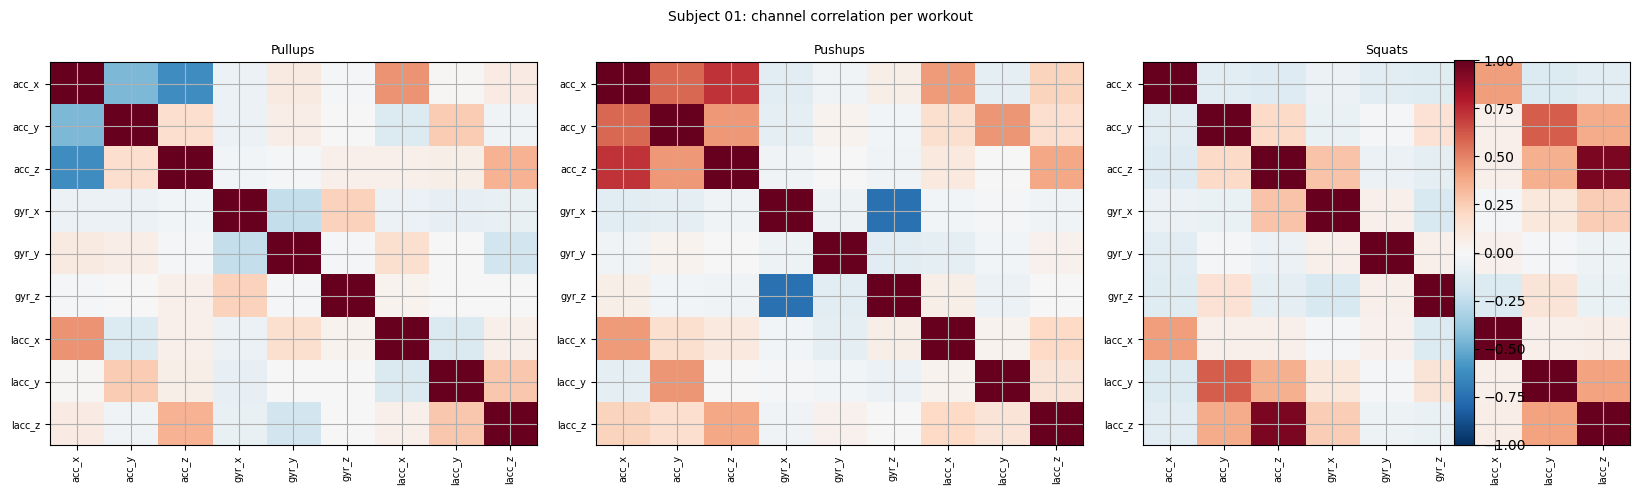

/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_56339/1945200046.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


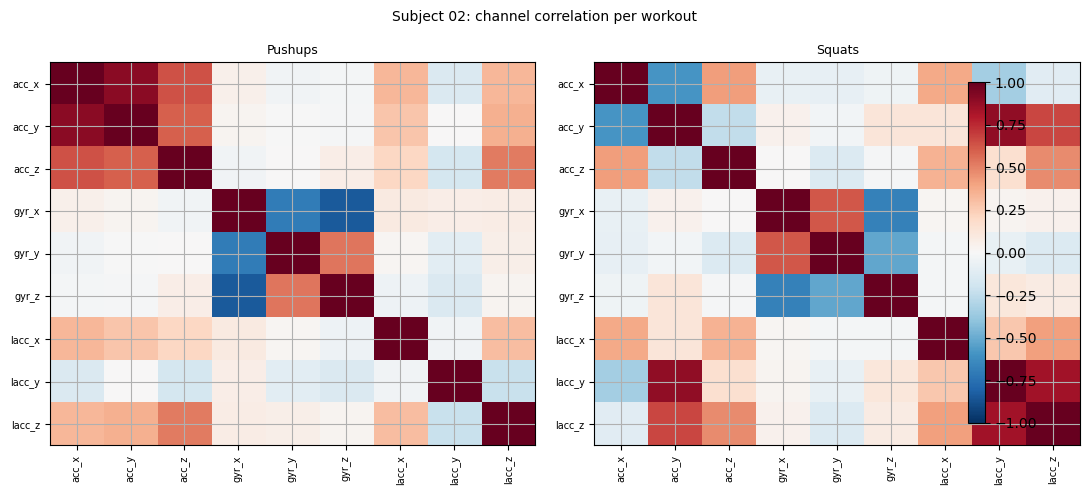

In [24]:
CORR_SENSORS = ["accelerometer", "gyroscope", "linear_acc"]
GRID_STEP    = 1.0 / TARGET_HZ

def resample_df(df, grid):
    t = df.iloc[:, 0].to_numpy()
    return {c: np.interp(grid, t, df[c].to_numpy()) for c in df.columns[1:]}

for subj in subjects:
    subj_works = sorted(sessions[sessions.subject == subj].workout.unique())
    fig, axes = plt.subplots(1, len(subj_works),
                             figsize=(5.5 * len(subj_works), 5), squeeze=False)
    im = None
    for ax, work in zip(axes[0], subj_works):
        cols = {}
        for sname in CORR_SENSORS:
            d = get(subj, work, sname)
            if d is None: continue
            prefix = SENSOR_PREFIX[sname]
            grid   = np.arange(d.iloc[0, 0], d.iloc[-1, 0], GRID_STEP)
            for cname, vals in resample_df(d, grid).items():
                short = re.sub(r"\s*\(.*\)", "", cname).strip().lower()
                cols[f"{prefix}_{short}"] = vals
        if not cols:
            ax.set_visible(False); continue
        min_len = min(len(v) for v in cols.values())
        corr    = pd.DataFrame({k: v[:min_len] for k, v in cols.items()}).corr()
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
        ax.set_xticks(range(len(corr)))
        ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
        ax.set_yticks(range(len(corr)))
        ax.set_yticklabels(corr.columns, fontsize=7)
        ax.set_title(work, fontsize=9)
    if im is not None:
        fig.colorbar(im, ax=axes[0], fraction=0.02, pad=0.04)
    fig.suptitle(f"Subject {subj}: channel correlation per workout", fontsize=10)
    plt.tight_layout(); plt.show()

## 6. Statistics at different time grains (Δt)

Non-overlapping windows of Δt seconds; mean/std/min/max per axis per sensor.
The tables can be used directly as feature tables for classification.

In [25]:
def window_stats(df, dt_sec):
    t     = df.iloc[:, 0].to_numpy()
    edges = np.arange(t[0], t[-1], dt_sec)
    rows  = []
    for start in edges:
        mask  = (t >= start) & (t < start + dt_sec)
        if mask.sum() < 2: continue
        chunk = df.iloc[mask, 1:4] if df.shape[1] >= 4 else df.iloc[mask, 1:2]
        stat  = {}
        for c in chunk.columns:
            short = re.sub(r"\s*\(.*\)", "", c).strip().lower()
            stat[f"{short}_mean"] = chunk[c].mean()
            stat[f"{short}_std"]  = chunk[c].std()
            stat[f"{short}_min"]  = chunk[c].min()
            stat[f"{short}_max"]  = chunk[c].max()
        rows.append(stat)
    return pd.DataFrame(rows)

def stats_for_entry(key, dt_sec):
    parts = []
    for sname, d in raw_combined[key].items():
        if d is None: continue
        prefix = SENSOR_PREFIX[sname]
        ws     = window_stats(d, dt_sec)
        if ws.empty: continue
        ws.columns = [f"{prefix}_{c}" for c in ws.columns]
        ws.index   = range(len(ws))
        parts.append(ws)
    return pd.concat(parts, axis=1) if parts else pd.DataFrame()

stat_tables = {}
for dt in TIME_GRAINS:
    rows = []
    for _, s in sessions.iterrows():
        ws = stats_for_entry(s.key, dt)
        if ws.empty: continue
        ws.insert(0, "subject",     s.subject)
        ws.insert(1, "workout",     s.workout)
        ws.insert(2, "window_dt_s", dt)
        rows.append(ws)
    stat_tables[dt] = pd.concat(rows, ignore_index=True)
    print(f"Δt={dt:2d}s → {len(stat_tables[dt]):4d} windows × {stat_tables[dt].shape[1]} columns")

Δt=10s →   75 windows × 55 columns
Δt= 5s →  147 windows × 55 columns
Δt= 2s →  362 windows × 55 columns


In [32]:
def grained_stats(df, dt_sec):
    t     = df.iloc[:, 0].to_numpy()
    edges = np.arange(t[0], t[-1], dt_sec)
    coarse = []
    for start in edges:
        mask = (t >= start) & (t < start + dt_sec)
        if mask.sum() < 1: continue
        chunk = df.iloc[mask, 1:4] if df.shape[1] >= 4 else df.iloc[mask, 1:2]
        coarse.append(chunk.mean().to_dict())

    coarse_df = pd.DataFrame(coarse).dropna()   # ← drop incomplete intervals

    stat = {}
    for c in coarse_df.columns:
        short = re.sub(r"\s*\(.*\)", "", c).strip().lower()
        stat[f"{short}_mean"] = coarse_df[c].mean()
        stat[f"{short}_std"]  = coarse_df[c].std()
        stat[f"{short}_min"]  = coarse_df[c].min()
        stat[f"{short}_max"]  = coarse_df[c].max()
    return stat

rows = []
for dt in TIME_GRAINS:
    for _, s in sessions.iterrows():
        row = {"subject": s.subject, "workout": s.workout, "delta_t": dt}
        for sname, d in raw_combined[s.key].items():
            if d is None: continue
            prefix = SENSOR_PREFIX[sname]
            stat   = grained_stats(d, dt)          # one sensor at a time
            row.update({f"{prefix}_{k}": v for k, v in stat.items()})
        rows.append(row)

grained_summary = pd.DataFrame(rows)

# Compare across Δt — one table per workout
for work in works:
    print(f"\n── {work} ──────────────────────────────")
    sub = grained_summary[grained_summary.workout == work]
    acc_cols = [c for c in sub.columns if c.startswith("acc_")][:6]
    display(sub[["subject","delta_t"] + acc_cols].sort_values(["subject","delta_t"]))


── Pullups ──────────────────────────────


,subject,delta_t,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std
10,01,2,7.377828,2.070475,0.845768,9.394691,1.525046,2.564151
5,01,5,7.342195,1.824761,2.486235,9.094252,1.532699,1.895465
0,01,10,7.168629,1.914305,2.486235,8.855442,1.564001,1.666504



── Pushups ──────────────────────────────


,subject,delta_t,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std
11,01,2,-3.473496,2.253943,-7.039166,1.615085,7.834287,1.135493
6,01,5,-3.419800,1.993537,-6.186931,1.188048,7.831095,0.866042
1,01,10,-3.471605,1.696128,-5.757065,0.106837,7.831773,0.773911
13,02,2,-5.052822,1.954116,-8.026565,0.046406,6.800801,1.512134
8,02,5,-4.984222,1.835296,-7.596686,-1.303334,6.857631,1.470047
3,02,10,-4.878383,1.819297,-7.557958,-2.224582,6.945484,1.462674



── Squats ──────────────────────────────


,subject,delta_t,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std
12,01,2,0.538113,1.086953,-2.366959,3.012515,2.260477,0.829369
7,01,5,0.547891,1.036182,-2.012762,2.778081,2.256447,0.617250
2,01,10,0.585950,0.945105,-1.570350,1.768788,2.276125,0.535703
14,02,2,1.439138,0.699139,-0.021323,2.588893,7.587596,0.708228
9,02,5,1.425722,0.491940,0.421109,2.235459,7.573070,0.395851
4,02,10,1.440875,0.441929,0.655979,1.957651,7.571881,0.231972


## 7. Rep cadence (Welch spectrum)

Dominant frequency of the linear-acc magnitude ≈ rep rate.

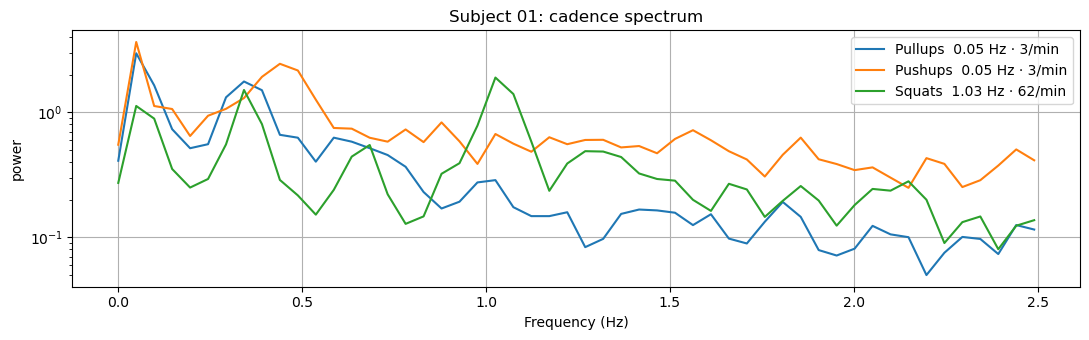

In [29]:
def cadence_spectrum(df, fs=50.0):
    m = magnitude(df) - magnitude(df).mean()
    return signal.welch(m, fs=fs, nperseg=min(1024, len(m)))

fig, ax = plt.subplots(figsize=(11, 3.5))
for work in works:
    d = get(subjects[0], work, "linear_acc")
    if d is None: continue
    f, pxx = cadence_spectrum(d, fs=hz(d))
    band   = f <= FMAX
    fpk    = f[band][np.argmax(pxx[band])]
    ax.semilogy(f[band], pxx[band],
                label=f"{work}  {fpk:.2f} Hz · {fpk*60:.0f}/min")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("power")
ax.set_title(f"Subject {subjects[0]}: cadence spectrum")
ax.legend(); plt.tight_layout(); plt.show()